In [104]:
import os
dir = os.path.abspath('')  # directory of notebook
import sys
sys.path.append(os.path.join(dir, '..', '..'))  # package directory
from src.FoKL import FoKLRoutines
from src.FoKL.fokl_to_pyomo import fokl_to_pyomo
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pyomo.dae as dae
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

In [105]:
INV_CP = False  # use parameters found with inv_CpH and inv_CpS

## Training Data

Linear regression performed in *tclab_training.ipynb*.

In [106]:
alpha = 0.00016  # watts / (units P1 * percent U1)
P1 = 200  # P1 units

if INV_CP:  # via 'tclab_training.ipynb' with inv_CpH and inv_CpS
    Ua  = 0.05405229846011348
    Ub  = 0.05294170189601992
    CpH = 6.055477666513158
    CpS = 1.004922603766054
else:  # via 'tclab_training.ipynb' with CpH and CpS
    Ua  = 0.052384291033157684
    Ub  = 0.060521133829919416
    CpH = 5.568800661406845
    CpS = 1.2773885658179458
param = [Ua, Ub, CpH, CpS]

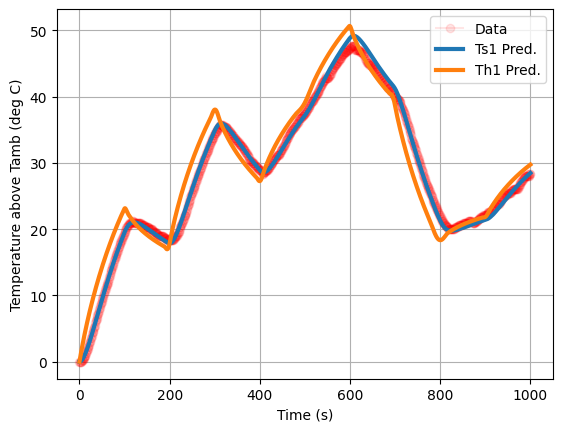

In [107]:
data = pd.read_csv(os.path.join(dir, "data", "step_tests.csv"))
tvec = data["Time"].values
Tamb = data["T1"].values[0]
Ts1 = data["T1"].values - Tamb
u1 = data["Q1"].values

u1_interp = interp1d(tvec, u1, kind='previous')

def tclab_model(param):
    Ua, Ub, CpH, CpS = param  # adjustable parameters

    def deriv(t, y):  # two-state model
        T1H, T1S = y
        dT1H = (-Ua * T1H + Ub * (T1S - T1H) + alpha * P1 * u1_interp(t)) / CpH
        dT1S = Ub * (T1H - T1S) / CpS
        return [dT1H, dT1S]
    
    soln = solve_ivp(deriv, [tvec[0], tvec[-1]], [0, 0], t_eval=tvec)  # model solution
    
    pred = pd.DataFrame()  # dataframe with predictions
    pred["Time"] = tvec
    pred["TH1"] = soln.y[0]
    pred["TS1"] = soln.y[1]
    pred["Q1"] = u1_interp(tvec)

    return pred


pred = tclab_model(param)
Th1_p = pred["TH1"].values
Ts1_p = pred["TS1"].values

%matplotlib inline
plt.plot(tvec, Ts1, marker='o', color='red', alpha=0.1)
plt.plot(tvec, Ts1_p, linewidth=3)
plt.plot(tvec, Th1_p, linewidth=3)
plt.xlabel("Time (s)")
plt.ylabel("Temperature above Tamb (deg C)")
plt.legend(["Data", "Ts1 Pred.", "Th1 Pred."])
plt.grid()
plt.show()

## GP Model

Training on $\{R\ |\ T_{H,1},\ T_{S,1},\ u_1\}$ was found to be the best from the perspective of the GP; however, issues arose in Pyomo as large gaps between $T_{H,1}$ and $T_{S,1}$ resulted in absurdly inaccurate GP evaluations, i.e., residuals.

It was attempted to train on $\{R\ |\ T_{H,1}-T_{S,1},\ T_{S,1},\ u_1\}$ so that the difference between $T_{H,1}$ and $T_{S,1}$ would be embedded within the GP's normalization bounds, but the bounds from the training data were too narrow to apply to the setpoint. Since the difference between $T_{H,1}$ and $T_{S,1}$ for the setpoint prediction is greater than the maximum difference in the step tests training data, the GP was not generalizable. While convenient to be embedded in the normalization bounds, the Pyomo model became more complex as a ```m.Th1mTs1``` variable for $T_{H,1}-T_{S,1}$ was required. Opting instead to maintain $\{R\ |\ T_{H,1},\ T_{S,1},\ u_1\}$ but with the maximum difference between the states constrained by Pyomo.

Various attempts were tried in Pyomo to constrain the difference of the states, such as adding an objective penalty to minimize the integral of the residual squared (to drive the residual near zero), or including the error of $T_{H,1}$ also with respect to the setpoint so that the penalty increases with the difference, or bounding the residual to physically meaningful values (e.g., +/- 5), or constraining the difference between the two states, etc.

Note that physically it is not expected for $u_1$ to impact $R$, though more data is often beneficial for the GP; so, $u_1$ is included in the training set.

In [108]:
R = Ts1 - Ts1_p

In [109]:
GP = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True, way3=True)

# _ = GP.fit([Th1_p, Ts1_p, u1], R, clean=True)

z = np.zeros(int(len(R) * 0.01))
_ = GP.fit([np.concatenate([z, Th1_p]), 
            np.concatenate([z, Ts1_p]), 
            np.concatenate([z, u1])], 
            np.concatenate([z, R]), 
            clean=True)

[1, -381.28970776378924]
[2, -1053.9353110713755]
[2, -1124.5129626433472]
[3, -1153.8855879725752]
[3, -1804.8598282103826]
[3, -1895.4669462083739]
[4, -2061.653833892366]
[4, -2161.0471362169596]
[4, -2232.252495957611]
[4, -2313.463855313249]
[5, -2398.5354730064655]
[5, -2429.7234271214993]
[5, -2724.6727113746115]
[5, -2796.9974564582008]
[5, -2819.5343678999243]
[6, -2820.8006012517844]
[6, -2920.3941297301317]
[6, -2927.038102111173]
[6, -2975.329855604803]
[6, -2988.225015791958]
[6, -2992.767684254786]
[7, -3097.9816961820025]
[7, -3092.328331638595]
[7, -3129.159792476885]
[7, -2593.5446949999364]
[7, -2886.2189508221877]
[7, -571.7123739836504]


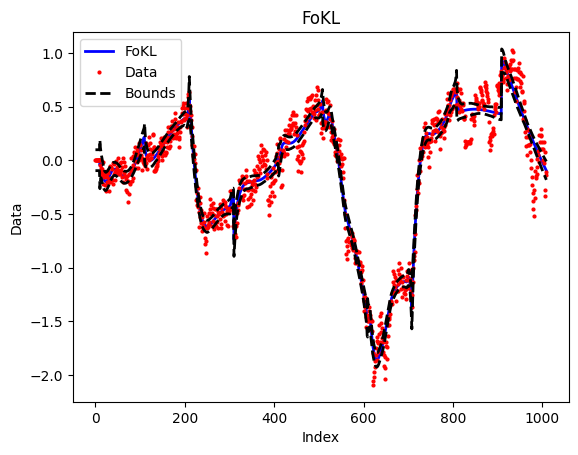

In [110]:
_ = GP.coverage3(plot=True)

## Setpoint

In [111]:
tvec = [0, 50, 150, 450, 550, 1000]

def r(t):
    return np.interp(t, tvec, [0, 0, 25, 25, 10, 10])

## Pyomo

In [112]:
tee = False  # IPOPT output
weight_ise = 1  # weight for ISE
weight_u1 = 0.1  # weight for sum_du1
# weight_R = 0  # weight for R_penalty
# MINIMIZE_RMAX = True  # minimize extreme R value, else minimize integral of R squared

In [113]:
def plot_soln(m, title, GP_OBJECTIVE=False):
    fig, ax = plt.subplots(3, sharex=True, figsize=(12, 9))
    fig.suptitle(title)
    fig.supxlabel("Time (s)")
    ax[0].set_ylabel("Temperature (deg C)")
    ax[1].set_ylabel("Heater Power (%)")
    ax[2].set_ylabel("Residual (deg C)")

    ax[0].plot(tvec, r(tvec) + Tamb, 'k', label="Tset")
    ax[0].plot(m.t, m.Th1[:]() + Tamb, '--g', label="Th1 (via Ts1)")
    ax[0].plot(m.t, m.Ts1[:]() + Tamb, 'g', label="Ts1")
    ax[0].plot(m.t, m.Th1_GP[:]() + Tamb, '--r', label="Th1 (via Ts1 + R)")
    ax[0].plot(m.t, m.Ts1_GP[:]() + Tamb, 'r', label="Ts1 + R")
    
    if GP_OBJECTIVE:
        col = 'r'
    else:
        col = 'g'
    ax[1].plot(m.t, m.u1[:](), col, label="u1")

    ax[2].plot(m.t, m.R[:](), 'k', label="R (i.e., GP)")
    ax[2].plot(m.t, r(m.t) - m.Ts1[:](), 'g', label="Tset - Ts1")
    ax[2].plot(m.t, r(m.t) - m.Ts1_GP[:](), 'r', label="Tset - (Ts1 + R)")

    for i in range(3):
        ax[i].legend()
        ax[i].grid()

    fig.tight_layout()

In [114]:
m = pyo.ConcreteModel("TCLab Benchmark")
m.t = dae.ContinuousSet(bounds=(tvec[0], tvec[-1]))

m.Th1 = pyo.Var(m.t, bounds=GP.minmax[0])
m.Ts1 = pyo.Var(m.t, bounds=GP.minmax[1])
m.u1 = pyo.Var(m.t, bounds=GP.minmax[2])

m.dTh1 = dae.DerivativeVar(m.Th1)
m.dTs1 = dae.DerivativeVar(m.Ts1)

m.Th1[0].fix(0.0)  # initial conditions
m.Ts1[0].fix(0.0)
m.u1[0].fix(0.0)

@m.Constraint(m.t)  # first differential equation
def heater1(m, t):
    return (
        CpH * m.dTh1[t]
        == -Ua * m.Th1[t] + Ub * (m.Ts1[t] - m.Th1[t]) + alpha * P1 * m.u1[t]
    )

@m.Constraint(m.t)  # second differential equation
def sensor1(m, t):
    return CpS * m.dTs1[t] == Ub * (m.Th1[t] - m.Ts1[t])

@m.Integral(m.t)  # integral of squared error
def ise(m, t):
    return (r(t) - m.Ts1[t]) ** 2

m.du1 = dae.DerivativeVar(m.u1)
@m.Integral(m.t)  # penalty term meant to smooth m.u1
def sum_du1(m, t):
    return m.du1[t] ** 2

# ===================================================
# FOR FOKL:

m.R = pyo.Var(m.t)  # residual
m.Th1_GP = pyo.Var(m.t)
m.Ts1_GP = pyo.Var(m.t)
m.dTh1_GP = dae.DerivativeVar(m.Th1_GP)

m.R[0].fix(0.0)
m.Th1_GP[0].fix(0.0)
m.Ts1_GP[0].fix(0.0)

fokl_to_pyomo(GP, [m.Th1, m.Ts1, m.u1], m.R, m, m.t)
m.GP0[0].deactivate()  # disable constraint at t0 since values fixed

@m.Constraint(m.t)  # first differential equation
def heater1_GP(m, t):
    return (
        CpH * m.dTh1_GP[t]
        == -Ua * m.Th1_GP[t] + Ub * (m.Ts1_GP[t] - m.Th1_GP[t]) + alpha * P1 * m.u1[t]
    )

@m.Constraint(m.t)  # GP correction via residual
def sensor1_GP(m, t):
    return m.Ts1_GP[t] == m.Ts1[t] + m.R[t]

@m.Integral(m.t)  # integral of squared error, with GP correction
def ise_GP(m, t):
    return (r(t) - m.Ts1_GP[t]) ** 2

if MINIMIZE_RMAX:
    m.R_penalty = pyo.Var(domain=pyo.NonNegativeReals)
    @m.Constraint(m.t)
    def Rmax_constr(m, t):
        return abs(m.R[t]) <= m.R_penalty
else:
    @m.Integral(m.t)
    def R_penalty(m, t):
        return m.R[t] ** 2

# END OF 'FOR FOKL'.
# ===================================================

pyo.TransformationFactory('dae.collocation').apply_to(m, nfe=200, wrt=m.t)

### Benchmark

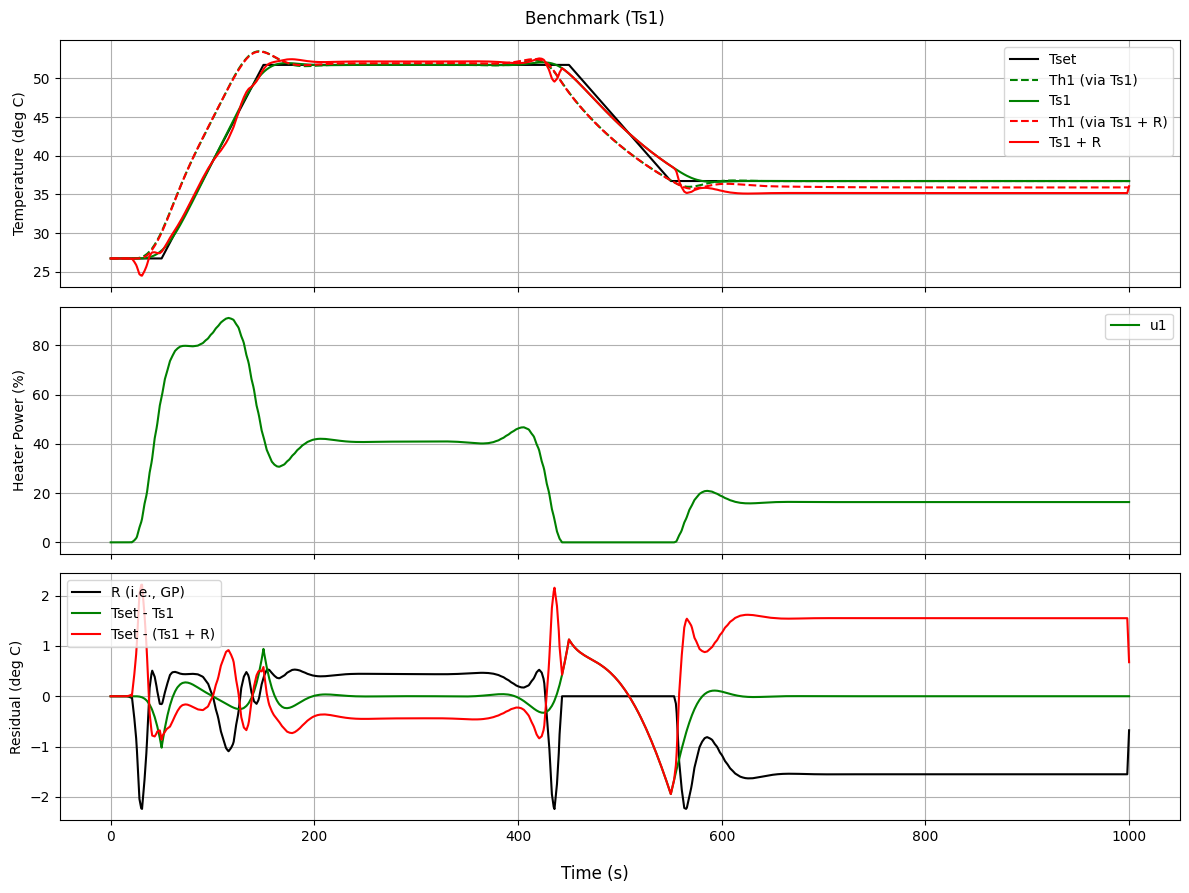

In [115]:
m.del_component("objective")

@m.Objective(sense=pyo.minimize)  # objective function
def objective(m):
    return weight_ise * m.ise + \
           weight_u1 * m.sum_du1

pyo.SolverFactory('ipopt').solve(m, tee=tee)
plot_soln(m, "Benchmark (Ts1)")

In [116]:
solution = pd.DataFrame()

solution["Time"] = m.t
solution["Q1"] = m.u1[:]()

solution.to_csv(os.path.join(dir, "data", "tclab_final_as_of_20240807__u_benchmark.csv"))

## GP

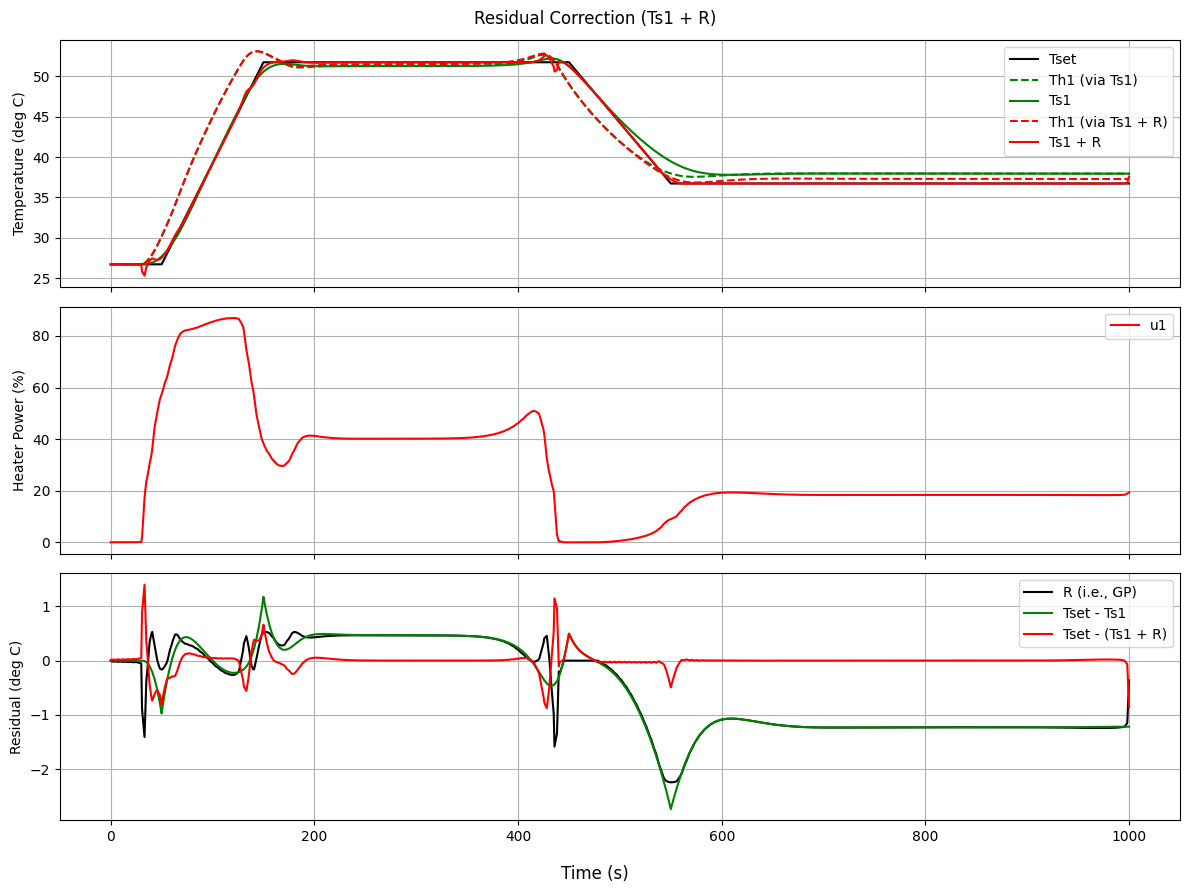

In [117]:
m.del_component("objective")

@m.Objective(sense=pyo.minimize)  # objective function
def objective(m):
    return weight_ise * m.ise_GP + \
           weight_u1 * m.sum_du1  # + \
           # weight_R * m.R_penalty

pyo.SolverFactory('ipopt').solve(m, tee=tee)
plot_soln(m, "Residual Correction (Ts1 + R)", True)

In [118]:
solution = pd.DataFrame()

solution["Time"] = m.t
solution["Q1"] = m.u1[:]()

solution.to_csv(os.path.join(dir, "data", "tclab_final_as_of_20240807__u_GP.csv"))

## TCLab Results

Running the saved $u_1$ solution on TCLab, the measured response is as follows.